Imports and Data Loading

In [8]:
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from tensorflow.keras.models import clone_model

# load data
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')
data = pd.concat([train_df, test_df], ignore_index=True)

Preprocessing

In [9]:
# encode labels
le = LabelEncoder()
data['label'] = le.fit_transform(data['Activity'])
num_classes = data['label'].nunique()

# split subjects
subjects = sorted(data['subject'].unique())
target_sub_id = 26
src_subjects = [s for s in subjects if s != target_sub_id]

time_stamps, channels = 63, 9
pad = time_stamps * channels

def prepare_data(df, scaler=None, fit_scaler=False):
    feature_cols = [c for c in df.columns if c not in ['Activity', 'label', 'subject']]
    X = df[feature_cols].values
    if fit_scaler:
        scaler.fit(X)
    X = scaler.transform(X)
    X = np.pad(X, ((0, 0), (0, pad - X.shape[1])))
    X = X.reshape(-1, time_stamps, channels)
    y = df['label'].values

    return X, y

# initialize scaler
scaler = StandardScaler()
X_src, y_src = prepare_data(data[data['subject'].isin(src_subjects)], scaler, fit_scaler=True)

Pre-training

In [13]:
import sys
import os
sys.path.append(os.path.abspath(".."))
from src.build_cnn import build_cnn

pretrained_model = build_cnn(input_shape=(time_stamps, channels), num_classes=num_classes)
pretrained_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print(f"Pre-training on source subjects")
history = pretrained_model.fit(X_src, y_src, epochs=10, batch_size=64, validation_split=0.1, verbose=1)

Pre-training on source subjects
Epoch 1/10
140/140 [==============================] - 5s 27ms/step - loss: 0.7464 - accuracy: 0.7067 - val_loss: 0.4996 - val_accuracy: 0.8073
Epoch 2/10
140/140 [==============================] - 5s 35ms/step - loss: 0.3090 - accuracy: 0.8776 - val_loss: 0.3150 - val_accuracy: 0.8850
Epoch 3/10
140/140 [==============================] - 6s 41ms/step - loss: 0.2105 - accuracy: 0.9217 - val_loss: 0.1903 - val_accuracy: 0.9354
Epoch 4/10
140/140 [==============================] - 6s 40ms/step - loss: 0.1669 - accuracy: 0.9353 - val_loss: 0.1215 - val_accuracy: 0.9556
Epoch 5/10
140/140 [==============================] - 5s 36ms/step - loss: 0.1474 - accuracy: 0.9429 - val_loss: 0.1472 - val_accuracy: 0.9455
Epoch 6/10
140/140 [==============================] - 5s 38ms/step - loss: 0.1214 - accuracy: 0.9551 - val_loss: 0.1244 - val_accuracy: 0.9556
Epoch 7/10
140/140 [==============================] - 5s 37ms/step - loss: 0.1043 - accuracy: 0.9591 - val_los

Transfer Learning & Optimizer Experiments

In [14]:
target_data = data[data['subject'] == target_sub_id].sample(frac=1, random_state=42)
X_trgt, y_trgt = prepare_data(target_data, scaler)

split = 50
X_fine, y_fine = X_trgt[:split], y_trgt[:split]
X_test, y_test = X_trgt[split:], y_trgt[split:]

def evaluate_variant(model, name):
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'F1 Score': round(f1_score(y_test, y_pred, average='macro'), 4)
    }

results = []

# pretrained
results.append(evaluate_variant(pretrained_model, 'Pretrained'))

# fine-tuned (Adam)
model_adam = clone_model(pretrained_model)
model_adam.set_weights(pretrained_model.get_weights())
model_adam.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_adam.fit(X_fine, y_fine, epochs=10, verbose=0)
results.append(evaluate_variant(model_adam, 'Fine-tuned (Adam)'))

# fine-tuned (SGD)
model_sgd = clone_model(pretrained_model)
model_sgd.set_weights(pretrained_model.get_weights())
model_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_sgd.fit(X_fine, y_fine, epochs=10, verbose=0)
results.append(evaluate_variant(model_sgd, 'Fine-tuned (SGD)'))

# baseline
baseline_model = build_cnn(input_shape=(time_stamps, channels), num_classes=num_classes)
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
baseline_model.fit(X_fine, y_fine, epochs=10, verbose=0)
results.append(evaluate_variant(baseline_model, 'Baseline'))

Comparison Table & Visualization

            Model  Accuracy  F1 Score
       Pretrained    0.9795    0.9824
Fine-tuned (Adam)    0.9883    0.9900
 Fine-tuned (SGD)    0.9795    0.9824
         Baseline    0.4561    0.3129


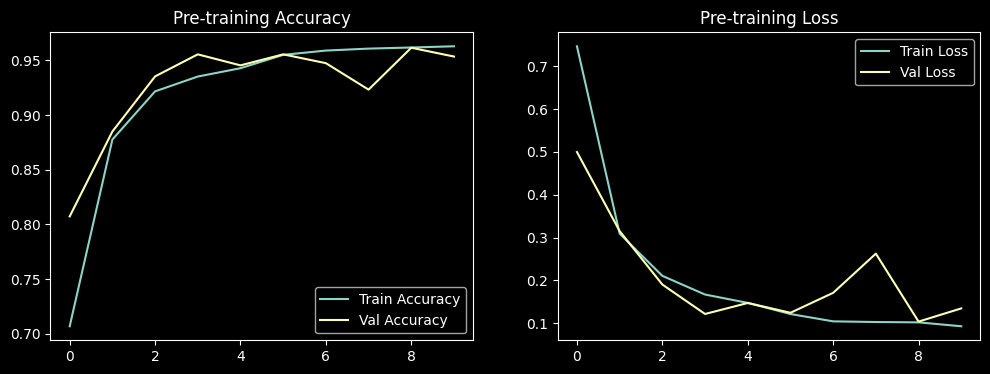

In [15]:
# results table
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Pre-training Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Pre-training Loss')
plt.legend()
plt.show()